<a href="https://colab.research.google.com/github/Anubhavkumar076/ai_data_analysis/blob/main/HR_Employee_Attrition_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

In [5]:
data = pd.read_csv('/content/HR_Employee_Attrition-1.csv')
data.sample()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2902,2903,No,37,Travel_Rarely,161,Research & Development,10,3,Life Sciences,1,3,Female,42,4,3,Research Director,4,Married,13744,15471,1,Y,Yes,25,4,1,80,1,16,2,3,16,11,6,8


In [6]:
data.head()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,2,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,3,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,4,No,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,5,No,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [7]:
data.tail()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2935,2936,No,36,Travel_Frequently,884,Research & Development,23,2,Medical,1,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
2936,2937,No,39,Travel_Rarely,613,Research & Development,6,1,Medical,1,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
2937,2938,No,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
2938,2939,No,49,Travel_Frequently,1023,Sales,2,3,Medical,1,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
2939,2940,No,34,Travel_Rarely,628,Research & Development,8,3,Medical,1,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            2940 non-null   int64 
 1   Attrition                 2940 non-null   object
 2   Age                       2940 non-null   int64 
 3   BusinessTravel            2940 non-null   object
 4   DailyRate                 2940 non-null   int64 
 5   Department                2940 non-null   object
 6   DistanceFromHome          2940 non-null   int64 
 7   Education                 2940 non-null   int64 
 8   EducationField            2940 non-null   object
 9   EmployeeCount             2940 non-null   int64 
 10  EnvironmentSatisfaction   2940 non-null   int64 
 11  Gender                    2940 non-null   object
 12  HourlyRate                2940 non-null   int64 
 13  JobInvolvement            2940 non-null   int64 
 14  JobLevel                

- There are no null value in all the column.
- Attrition, BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, Over18, OverTime have object type data type.

In [9]:
df = data.copy()

In [10]:
object_columns = df.select_dtypes(['object'])
object_columns.columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [11]:
for i in object_columns.columns:
  df[i] = df[i].astype('category')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   EmployeeNumber            2940 non-null   int64   
 1   Attrition                 2940 non-null   category
 2   Age                       2940 non-null   int64   
 3   BusinessTravel            2940 non-null   category
 4   DailyRate                 2940 non-null   int64   
 5   Department                2940 non-null   category
 6   DistanceFromHome          2940 non-null   int64   
 7   Education                 2940 non-null   int64   
 8   EducationField            2940 non-null   category
 9   EmployeeCount             2940 non-null   int64   
 10  EnvironmentSatisfaction   2940 non-null   int64   
 11  Gender                    2940 non-null   category
 12  HourlyRate                2940 non-null   int64   
 13  JobInvolvement            2940 non-null   int64 

In [18]:
df.nunique()

,0
EmployeeNumber,2940
Attrition,2
Age,43
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1


- EmployeeNumber is unique attribute
- Over18, EmployeeCount, StandardHous have only one value throughout the entries

These columns can be eliminated

In [19]:
df.drop(['EmployeeNumber', 'Over18', 'EmployeeCount', 'StandardHours'], axis=1, inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Attrition                 2940 non-null   category
 1   Age                       2940 non-null   int64   
 2   BusinessTravel            2940 non-null   category
 3   DailyRate                 2940 non-null   int64   
 4   Department                2940 non-null   category
 5   DistanceFromHome          2940 non-null   int64   
 6   Education                 2940 non-null   int64   
 7   EducationField            2940 non-null   category
 8   EnvironmentSatisfaction   2940 non-null   int64   
 9   Gender                    2940 non-null   category
 10  HourlyRate                2940 non-null   int64   
 11  JobInvolvement            2940 non-null   int64   
 12  JobLevel                  2940 non-null   int64   
 13  JobRole                   2940 non-null   catego

In [29]:
Y = df['Attrition']
X = df.drop('Attrition', axis=1)


In [36]:
Y.head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [35]:
Y= Y.apply(lambda x: 1 if x == 'Yes' else 0)

In [40]:
X = pd.get_dummies(X, drop_first=True)

In [41]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


In [44]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [47]:
def model_performance_classification(model, predictors, target):
  pred = model.predict(predictors)

  acc = accuracy_score(target, pred)
  recall = recall_score(target, pred)
  precision = precision_score(target, pred)
  f1 = f1_score(target, pred)

  scored = pd.DataFrame(
      {
          "Accuracy" : acc,
          "Recall Score" : recall,
          "Precision Score" : precision,
          "F1 Score" : f1
      }, index=[0]
  )

  return scored


In [57]:
def confusion_matrix_sklearn(model, predictors, target):
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2,2)

    plt.figure(figsize=(10,10))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [23]:
dtree = DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42)

In [45]:
dtree.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [55]:
dtree_train_performance = model_performance_classification(dtree, x_train, y_train)
dtree_train_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,1.0,1.0,1.0,1.0


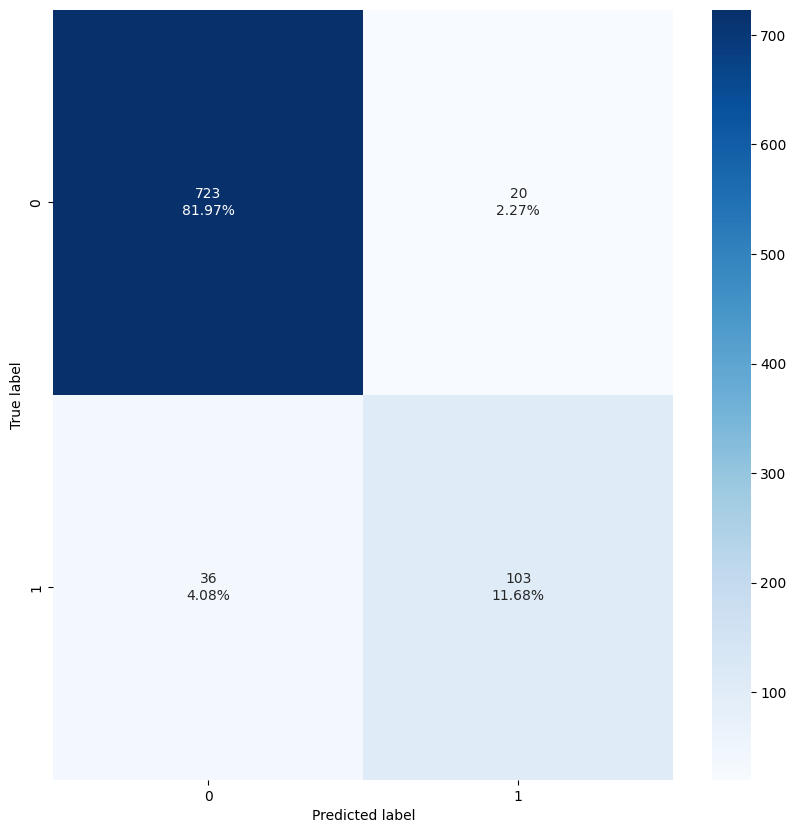

In [58]:
confusion_matrix_sklearn(dtree, x_test, y_test)

In [59]:
dtree_test_performance = model_performance_classification(dtree, x_test, y_test)
dtree_test_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.936508,0.741007,0.837398,0.78626


In [61]:
bagging = BaggingClassifier(random_state=42)
bagging.fit(x_train, y_train)

BaggingClassifier(random_state=42)

In [62]:
bagging_train_performance = model_performance_classification(bagging, x_train, y_train)
bagging_train_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.996113,0.976119,1.0,0.987915


In [63]:
bagging_test_performance = model_performance_classification(bagging, x_test, y_test)
bagging_test_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.938776,0.640288,0.956989,0.767241


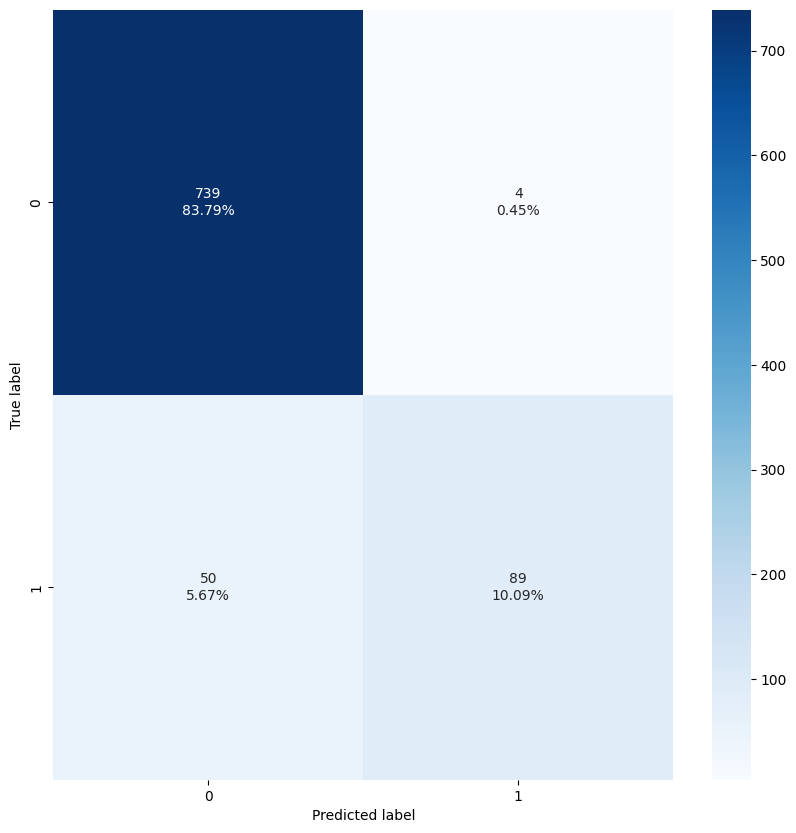

In [64]:
confusion_matrix_sklearn(bagging, x_test, y_test)

Bagging with hyperparameter

In [66]:
bagging_hyper = BaggingClassifier(DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42), random_state=42)
bagging_hyper.fit(x_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                   random_state=42),
                  random_state=42)

In [68]:
bagging_hyper_train_performance = model_performance_classification(bagging_hyper, x_train, y_train)
bagging_hyper_train_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.996113,0.976119,1.0,0.987915


In [70]:
bagging_hyper_test_performance = model_performance_classification(bagging_hyper, x_test, y_test)
bagging_hyper_test_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.936508,0.640288,0.936842,0.760684


Random Forest

In [71]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [72]:
rf_train_performance = model_performance_classification(rf, x_train, y_train)
rf_train_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,1.0,1.0,1.0,1.0


In [73]:
rf_test_performance = model_performance_classification(rf, x_test, y_test)
rf_test_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.952381,0.697842,1.0,0.822034


In [77]:
rf_hyper = RandomForestClassifier(class_weight={0:0.17,1:0.83}, random_state=42)
rf_hyper.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.17, 1: 0.83}, random_state=42)

In [78]:
rf_hyper_train_performance = model_performance_classification(rf_hyper, x_train, y_train)
rf_hyper_train_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,1.0,1.0,1.0,1.0


In [79]:
rf_hyper_test_performance = model_performance_classification(rf_hyper, x_test, y_test)
rf_hyper_test_performance


,Accuracy,Recall Score,Precision Score,F1 Score
0,0.950113,0.683453,1.0,0.811966


Tuning Decision Tree

In [82]:
# Choose the type of classifier.
dtree_estimator = DecisionTreeClassifier(class_weight={0:0.17,1:0.83},random_state=1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2,30),
              'min_samples_leaf': [1, 2, 5, 7, 10],
              'max_leaf_nodes' : [2, 3, 5, 10,15],
              'min_impurity_decrease': [0.0001,0.001,0.01,0.1]
             }

# Run the grid search
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring='recall')
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
dtree_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_estimator.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.17, 1: 0.83}, max_depth=np.int64(7),
                       max_leaf_nodes=15, min_impurity_decrease=0.0001,
                       min_samples_leaf=7, random_state=1)

In [85]:
dtree_estimator_train_performance = model_performance_classification(dtree_estimator, x_train, y_train)
dtree_estimator_train_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.813411,0.746269,0.455373,0.565611


In [86]:
dtree_estimator_test_performance = model_performance_classification(dtree_estimator, x_test, y_test)
dtree_estimator_test_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.807256,0.690647,0.430493,0.530387


In [101]:
# grid search for bagging classifier
cl1 = DecisionTreeClassifier(class_weight={0:0.13,1:0.87},random_state=1)
param_grid = {
              'n_estimators':[5,7,15,51,101],
              'max_features': [0.7,0.8,0.9,1]
             }

# We must set refit to one of our scoring metrics (e.g., 'recall') to get the best_estimator_
grid = GridSearchCV(BaggingClassifier(cl1, random_state=1,bootstrap=True), refit='recall', param_grid=param_grid, scoring = ['f1', 'recall'], cv = 5)
grid.fit(x_train, y_train)

## getting the best estimator
bagging_estimator  = grid.best_estimator_
bagging_estimator.fit(x_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(class_weight={0: 0.13,
                                                                 1: 0.87},
                                                   random_state=1),
                  max_features=1, n_estimators=51, random_state=1)

In [102]:
bagging_estimator_train_performance = model_performance_classification(bagging_estimator, x_train, y_train)
bagging_estimator_train_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.374636,0.98806,0.205081,0.339661


In [103]:
bagging_estimator_test_performance = model_performance_classification(bagging_estimator, x_test, y_test)
bagging_estimator_test_performance

,Accuracy,Recall Score,Precision Score,F1 Score
0,0.336735,0.956835,0.186798,0.312573


In [104]:
rf_estimator = RandomForestClassifier(class_weight={0:0.17,1:0.83},random_state=1)

# Grid of parameters to choose from
parameters = {
        "n_estimators": [110,251,501],
        "min_samples_leaf": np.arange(1, 6,1),
        "max_features": [0.7,0.9,'log2','auto'],
        "max_samples": [0.7,0.9,None],
}

grid_obj = GridSearchCV(rf_estimator, parameters, scoring='recall', cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

rf_best_estimator = grid_obj.best_estimator_
rf_best_estimator.fit(x_train, y_train)

# Set the clf to the best combination of parameters

RandomForestClassifier(class_weight={0: 0.17, 1: 0.83}, max_features=0.7,
                       min_samples_leaf=np.int64(5), n_estimators=501,
                       random_state=1)